<a href="https://colab.research.google.com/github/atina-21/PengolahanCitra/blob/main/Jobsheet5_PengolahanCitra.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# JOBSHEET 05: MENGUKUR KEMIRIPAN CITRA DAN PENERAPANNYA DALAM PENGENALAN POLA

### Praktikum 1. Menghitung Jarak Berbasis Piksel (Euclidean & Manhattan)

Jarak Euclidean (Patch1 vs Patch2): 24.7650
Jarak Euclidean (Patch1 vs Patch3): 5.0000
Jarak Manhattan (Patch1 vs Patch2): 936.4392
Jarak Manhattan (Patch1 vs Patch3): 250.0000


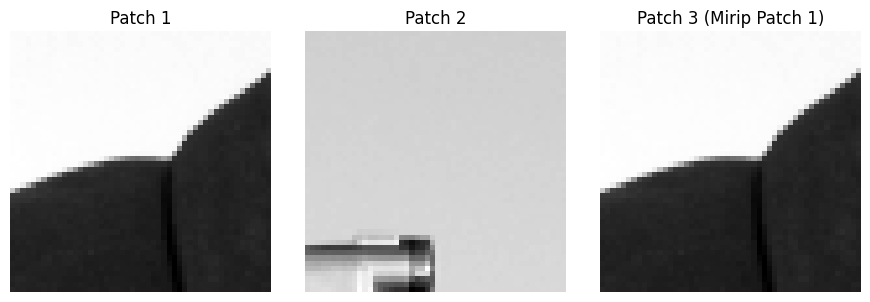

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import data, img_as_float
from scipy.spatial import distance

# 1. Ambil citra dan buat patch
image = img_as_float(data.camera())

patch1 = image[100:150, 100:150]
patch2 = image[100:150, 300:350]  # Patch dari lokasi berbeda

# Patch 3 = patch1 + sedikit noise
patch3 = patch1 + 0.1
patch3 = np.clip(patch3, 0, 1)  # Pastikan nilai tetap di [0, 1]

# 2. Flatten patch menjadi vektor 1D
vec1 = patch1.flatten()
vec2 = patch2.flatten()
vec3 = patch3.flatten()

# 3. Hitung jarak Euclidean (L2)
dist_l2_12 = distance.euclidean(vec1, vec2)
dist_l2_13 = distance.euclidean(vec1, vec3)

# 4. Hitung jarak Manhattan (L1 / cityblock)
dist_l1_12 = distance.cityblock(vec1, vec2)
dist_l1_13 = distance.cityblock(vec1, vec3)

# 5. Tampilkan hasil
print(f"Jarak Euclidean (Patch1 vs Patch2): {dist_l2_12:.4f}")
print(f"Jarak Euclidean (Patch1 vs Patch3): {dist_l2_13:.4f}")
print(f"Jarak Manhattan (Patch1 vs Patch2): {dist_l1_12:.4f}")
print(f"Jarak Manhattan (Patch1 vs Patch3): {dist_l1_13:.4f}")

# 6. Visualisasi patch
fig, axes = plt.subplots(1, 3, figsize=(9, 3))

axes[0].imshow(patch1, cmap='gray')
axes[0].set_title('Patch 1')
axes[0].axis('off')

axes[1].imshow(patch2, cmap='gray')
axes[1].set_title('Patch 2')
axes[1].axis('off')

axes[2].imshow(patch3, cmap='gray')
axes[2].set_title('Patch 3 (Mirip Patch 1)')
axes[2].axis('off')

plt.tight_layout()
plt.show()

### Praktikum 2. Menghitung Cosine Similarity antara Histogram Warna

Cosine Similarity (Image1 vs Image2 - Astronaut vs Coffee): 0.8156
Cosine Similarity (Image1 vs Image3 - Same Image): 1.0000
Cosine Similarity (Image1 vs Image4 - Downsampled): 1.0000


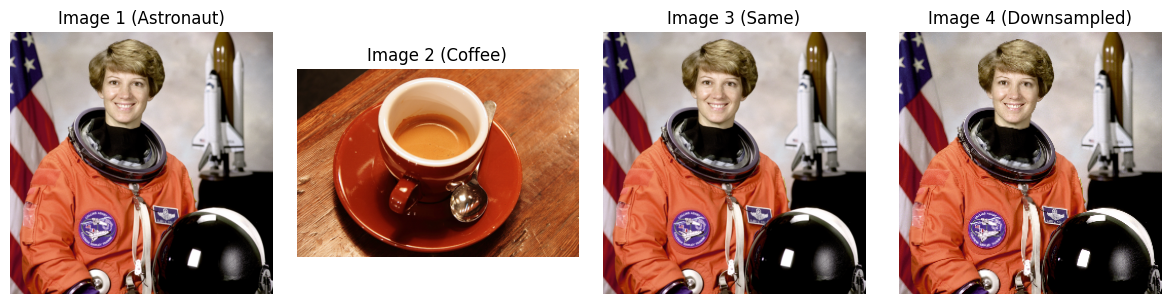

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import data, img_as_ubyte
from scipy.spatial import distance

# Fungsi untuk menghitung histogram RGB gabungan
def calculate_rgb_histogram(image, bins=16):
    img_uint8 = img_as_ubyte(image)

    hist_r, _ = np.histogram(img_uint8[:, :, 0].ravel(), bins=bins, range=(0, 256))
    hist_g, _ = np.histogram(img_uint8[:, :, 1].ravel(), bins=bins, range=(0, 256))
    hist_b, _ = np.histogram(img_uint8[:, :, 2].ravel(), bins=bins, range=(0, 256))

    # Gabungkan histogram R, G, B
    hist_combined = np.concatenate((hist_r, hist_g, hist_b))

    # Normalisasi
    hist_combined = hist_combined.astype(float) / np.sum(hist_combined)

    return hist_combined


# 1. Muat citra
try:
    image1 = data.astronaut()
    image2 = data.coffee()
    image3 = data.astronaut()           # Sama dengan image1
    image4 = image1[::2, ::2, :]        # Downsampled
except Exception as e:
    print(f"Gagal memuat data skimage: {e}. Membuat citra dummy.")
    image1 = np.random.rand(100, 100, 3)
    image2 = np.random.rand(100, 100, 3) * 0.5
    image3 = image1.copy()
    image4 = image1[::2, ::2, :]


# 2. Hitung histogram
hist1 = calculate_rgb_histogram(image1)
hist2 = calculate_rgb_histogram(image2)
hist3 = calculate_rgb_histogram(image3)
hist4 = calculate_rgb_histogram(image4)


# 3. Hitung Cosine Similarity
sim_12 = 1 - distance.cosine(hist1, hist2)
sim_13 = 1 - distance.cosine(hist1, hist3)
sim_14 = 1 - distance.cosine(hist1, hist4)


# 4. Tampilkan hasil
print(f"Cosine Similarity (Image1 vs Image2 - Astronaut vs Coffee): {sim_12:.4f}")
print(f"Cosine Similarity (Image1 vs Image3 - Same Image): {sim_13:.4f}")
print(f"Cosine Similarity (Image1 vs Image4 - Downsampled): {sim_14:.4f}")


# 5. Visualisasi
fig, axes = plt.subplots(1, 4, figsize=(12, 3))

axes[0].imshow(image1)
axes[0].set_title('Image 1 (Astronaut)')
axes[0].axis('off')

axes[1].imshow(image2)
axes[1].set_title('Image 2 (Coffee)')
axes[1].axis('off')

axes[2].imshow(image3)
axes[2].set_title('Image 3 (Same)')
axes[2].axis('off')

axes[3].imshow(image4)
axes[3].set_title('Image 4 (Downsampled)')
axes[3].axis('off')

plt.tight_layout()
plt.show()

### Praktikum 3. Menghitung Structural Similarity Index (SSIM)

SSIM (Ref vs Same): 1.0000
SSIM (Ref vs Noisy): 0.2953
SSIM (Ref vs Contrast): 0.9651
SSIM (Ref vs Blurred): 0.8027


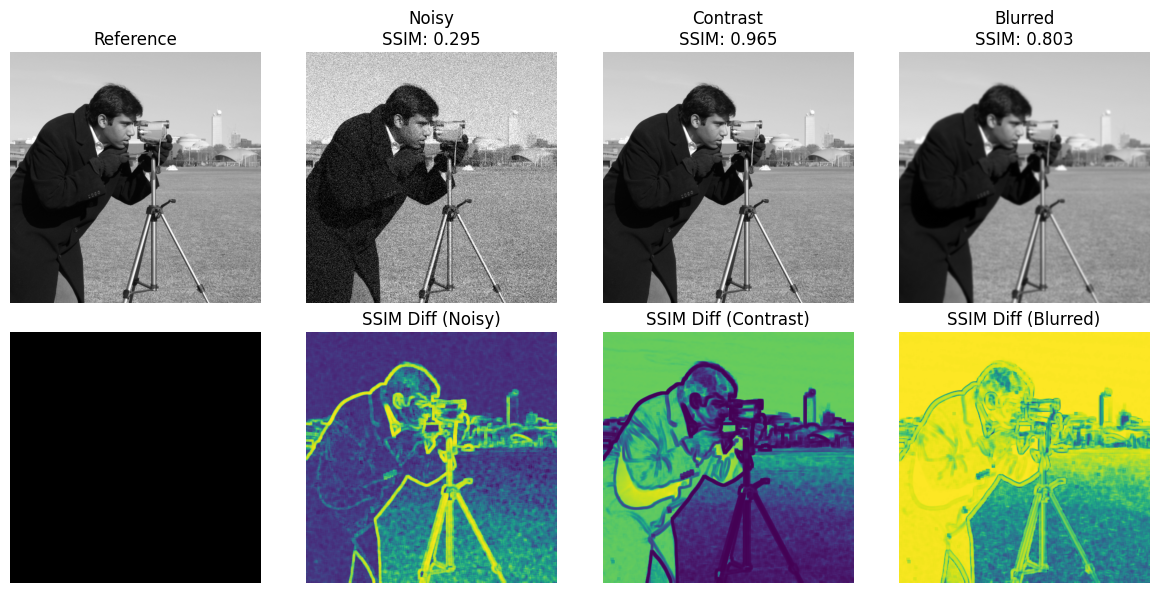

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import data, img_as_float
from skimage.metrics import structural_similarity as ssim
from skimage.util import random_noise
from skimage.filters import gaussian

# 1. Muat citra referensi
image_ref = img_as_float(data.camera())

# 2. Buat beberapa versi citra terdistorsi
image_same = image_ref.copy()  # Sama persis
image_noisy = random_noise(image_ref, mode='gaussian', var=0.01)  # Noise
image_contrast = np.clip(image_ref * 0.8, 0, 1)  # Kontras turun
image_blurred = gaussian(image_ref, sigma=1.5, channel_axis=None)  # Blur

# 3. Hitung SSIM
data_range = image_ref.max() - image_ref.min()

ssim_same, _ = ssim(image_ref, image_same, data_range=data_range, full=True)
ssim_noisy, diff_noisy = ssim(image_ref, image_noisy, data_range=data_range, full=True)
ssim_contrast, diff_contrast = ssim(image_ref, image_contrast, data_range=data_range, full=True)
ssim_blurred, diff_blurred = ssim(image_ref, image_blurred, data_range=data_range, full=True)

# 4. Tampilkan hasil
print(f"SSIM (Ref vs Same): {ssim_same:.4f}")
print(f"SSIM (Ref vs Noisy): {ssim_noisy:.4f}")
print(f"SSIM (Ref vs Contrast): {ssim_contrast:.4f}")
print(f"SSIM (Ref vs Blurred): {ssim_blurred:.4f}")

# 5. Visualisasi
fig, axes = plt.subplots(2, 4, figsize=(12, 6))
ax = axes.ravel()

# Baris atas (citra)
ax[0].imshow(image_ref, cmap='gray')
ax[0].set_title('Reference')
ax[0].axis('off')

ax[1].imshow(image_noisy, cmap='gray')
ax[1].set_title(f'Noisy\nSSIM: {ssim_noisy:.3f}')
ax[1].axis('off')

ax[2].imshow(image_contrast, cmap='gray')
ax[2].set_title(f'Contrast\nSSIM: {ssim_contrast:.3f}')
ax[2].axis('off')

ax[3].imshow(image_blurred, cmap='gray')
ax[3].set_title(f'Blurred\nSSIM: {ssim_blurred:.3f}')
ax[3].axis('off')

# Baris bawah (peta perbedaan)
ax[4].imshow(np.zeros_like(image_ref), cmap='gray')
ax[4].set_title('')
ax[4].axis('off')

ax[5].imshow(diff_noisy, cmap='viridis')
ax[5].set_title('SSIM Diff (Noisy)')
ax[5].axis('off')

ax[6].imshow(diff_contrast, cmap='viridis')
ax[6].set_title('SSIM Diff (Contrast)')
ax[6].axis('off')

ax[7].imshow(diff_blurred, cmap='viridis')
ax[7].set_title('SSIM Diff (Blurred)')
ax[7].axis('off')

plt.tight_layout()
plt.show()

### Praktikum 4. Penerapan Template Matching

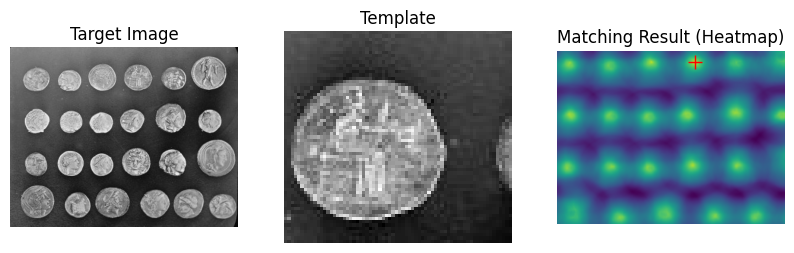

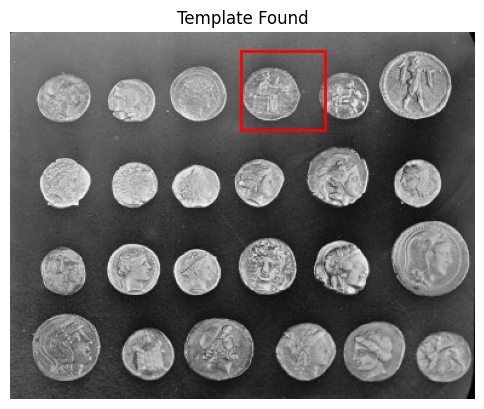

Template ditemukan di koordinat (x, y): (190, 15)


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import data
from skimage.feature import match_template

# 1. Muat citra target dan template
image = data.coins()

# Ambil salah satu koin sebagai template (sesuaikan jika perlu)
template = image[15:80, 190:260]

# 2. Template matching (Normalized Cross-Correlation)
result = match_template(image, template)

# 3. Cari lokasi dengan nilai korelasi tertinggi
ij = np.unravel_index(np.argmax(result), result.shape)
y, x = ij  # (row, col) → (y, x)

# 4. Visualisasi
fig, ax = plt.subplots(1, 3, figsize=(10, 4))

# Citra asli
ax[0].imshow(image, cmap='gray')
ax[0].set_title('Target Image')
ax[0].axis('off')

# Template
ax[1].imshow(template, cmap='gray')
ax[1].set_title('Template')
ax[1].axis('off')

# Heatmap hasil matching
ax[2].imshow(result, cmap='viridis')
ax[2].set_title('Matching Result (Heatmap)')
ax[2].axis('off')

# Tandai titik terbaik di heatmap
ax[2].plot(x, y, 'r+', markersize=10)

# Visualisasi hasil deteksi di citra asli
fig2, ax_main = plt.subplots(figsize=(6, 6))
ax_main.imshow(image, cmap='gray')
ax_main.set_title('Template Found')
ax_main.axis('off')

# Gambar kotak pada lokasi template
h, w = template.shape
rect = plt.Rectangle((x, y), w, h, edgecolor='r', facecolor='none', linewidth=2)
ax_main.add_patch(rect)

plt.show()

# Output koordinat
print(f"Template ditemukan di koordinat (x, y): ({x}, {y})")

### Praktikum 5. Simulasi Content-Based Image Retrieval (CBIR) Sederhana

Memproses database citra...
- astronaut diproses.
- camera diproses.
- coffee diproses.
- coins diproses.
- chelsea diproses.

Hasil Retrieval (semakin ke kanan, semakin tidak mirip):
Rank 1: chelsea (Distance: 0.000)
Rank 2: coins (Distance: 0.288)
Rank 3: coffee (Distance: 0.359)
Rank 4: astronaut (Distance: 0.461)
Rank 5: camera (Distance: 0.602)


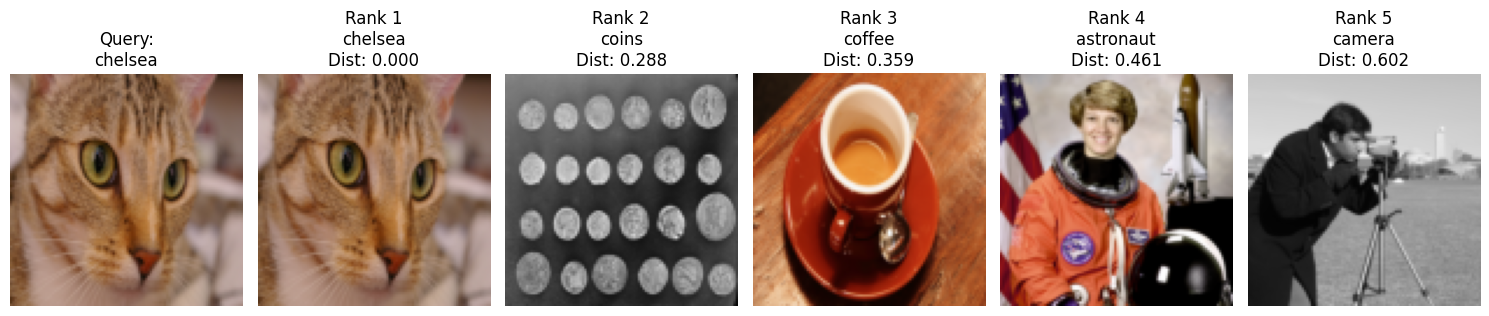

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import data, color, transform, img_as_float, img_as_ubyte
from scipy.spatial import distance

# Fungsi untuk menghitung histogram RGB
def calculate_rgb_histogram(image, bins=16):
    # Pastikan format uint8
    if image.dtype == float:
        image = img_as_ubyte(image)

    hist_r, _ = np.histogram(image[:, :, 0].ravel(), bins=bins, range=(0, 256))
    hist_g, _ = np.histogram(image[:, :, 1].ravel(), bins=bins, range=(0, 256))
    hist_b, _ = np.histogram(image[:, :, 2].ravel(), bins=bins, range=(0, 256))

    hist_combined = np.concatenate((hist_r, hist_g, hist_b))

    # Normalisasi L1
    hist_sum = np.sum(hist_combined)
    if hist_sum > 0:
        hist_combined = hist_combined.astype(float) / hist_sum
    else:
        hist_combined = hist_combined.astype(float)

    return hist_combined


# 1. Siapkan database citra
image_db_names = ["astronaut", "camera", "coffee", "coins", "chelsea"]
database_images = []
database_hists = []

print("Memproses database citra...")

for name in image_db_names:
    try:
        img = getattr(data, name)()

        # Jika grayscale → ubah ke RGB
        if img.ndim == 2:
            img = color.gray2rgb(img)

        # Resize agar konsisten
        img_resized = transform.resize(img, (100, 100), anti_aliasing=True)

        database_images.append(img_resized)
        database_hists.append(calculate_rgb_histogram(img_resized))

        print(f"- {name} diproses.")

    except Exception as e:
        print(f"Error memproses {name}: {e}")


# 2. Pilih query
query_image_name = "chelsea"
query_index = image_db_names.index(query_image_name)

query_image = database_images[query_index]
query_hist = database_hists[query_index]


# 3. Hitung jarak cosine
distances = []
for hist in database_hists:
    dist = distance.cosine(query_hist, hist)
    distances.append(dist)


# 4. Urutkan berdasarkan jarak
sorted_indices = np.argsort(distances)


# 5. Visualisasi hasil
num_results = len(database_images)
fig, axes = plt.subplots(1, num_results + 1, figsize=(15, 3))

# Tampilkan query
axes[0].imshow(query_image)
axes[0].set_title(f"Query:\n{query_image_name}")
axes[0].axis('off')

print("\nHasil Retrieval (semakin ke kanan, semakin tidak mirip):")

# Tampilkan hasil ranking
rank = 1
for idx in sorted_indices:
    ax = axes[rank]
    ax.imshow(database_images[idx])
    ax.set_title(f"Rank {rank}\n{image_db_names[idx]}\nDist: {distances[idx]:.3f}")
    ax.axis('off')

    print(f"Rank {rank}: {image_db_names[idx]} (Distance: {distances[idx]:.3f})")

    rank += 1

plt.tight_layout()
plt.show()

# PENUGASAN

/tmp/ipykernel_11741/1333384756.py:121: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


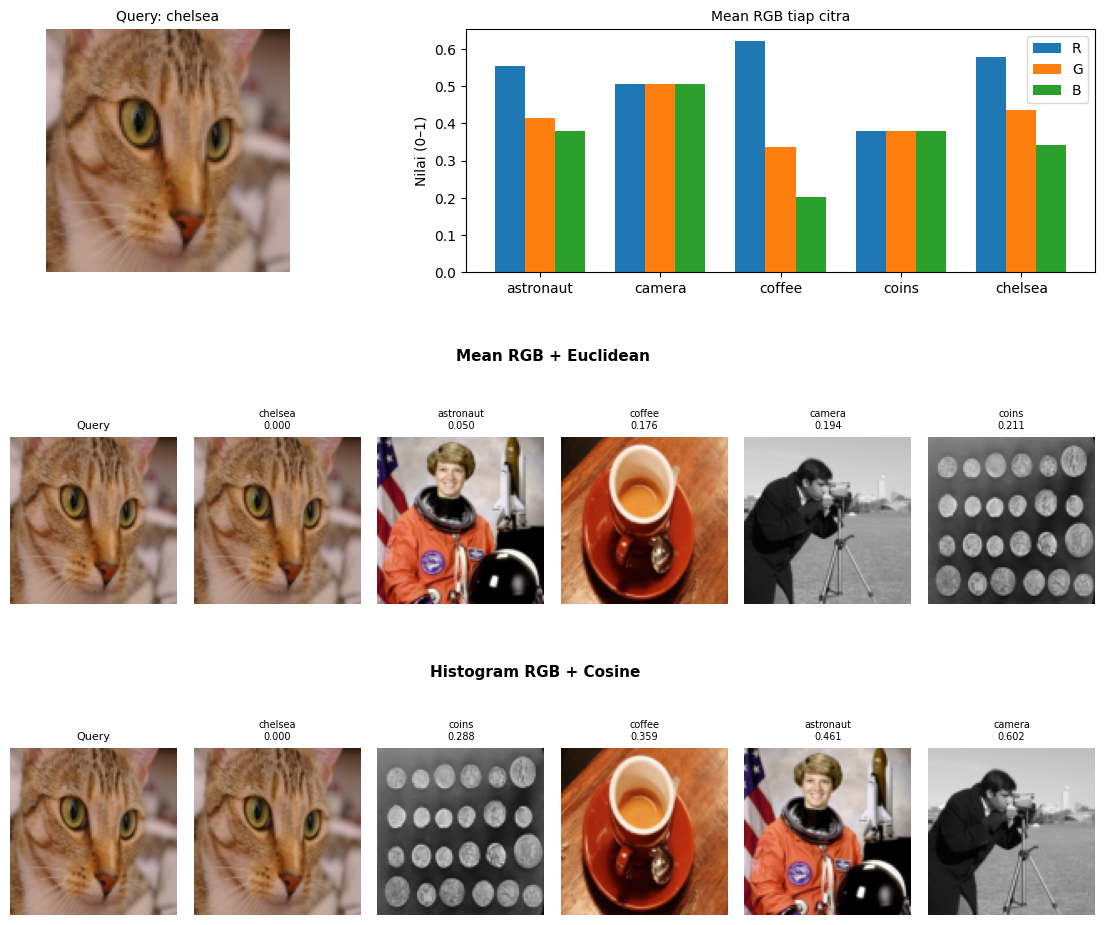

In [6]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from skimage import data, color, transform, img_as_ubyte
from scipy.spatial import distance

# ── helpers ──────────────────────────────────────────────
def calculate_rgb_histogram(image, bins=16):
    img_uint8 = img_as_ubyte(image)
    h = np.concatenate([
        np.histogram(img_uint8[:, :, i].ravel(), bins=bins, range=(0, 256))[0]
        for i in range(3)
    ]).astype(float)
    return h / h.sum()

def calculate_mean_rgb(image):
    return np.array([image[:, :, i].mean() for i in range(3)])

# ── build database ────────────────────────────────────────
names = ["astronaut", "camera", "coffee", "coins", "chelsea"]
imgs, hists, means = [], [], []

for n in names:
    img = getattr(data, n)()
    if img.ndim == 2:
        img = color.gray2rgb(img)
    img = transform.resize(img, (100, 100), anti_aliasing=True)
    imgs.append(img)
    hists.append(calculate_rgb_histogram(img))
    means.append(calculate_mean_rgb(img))

# ── query ─────────────────────────────────────────────────
qi = names.index("chelsea")
q_img = imgs[qi]
q_hist = hists[qi]
q_mean = means[qi]

cosine_d = [distance.cosine(q_hist, h) for h in hists]
euclidean_d = [distance.euclidean(q_mean, m) for m in means]

rank_cos = np.argsort(cosine_d)
rank_euc = np.argsort(euclidean_d)

fig = plt.figure(figsize=(14, 12), facecolor='white')
gs = gridspec.GridSpec(3, 1, figure=fig, hspace=0.4)

# ── (A) Query + Bar Chart ─────────────────────────────────
gsa = gridspec.GridSpecFromSubplotSpec(
    1, 2, subplot_spec=gs[0], wspace=0.3, width_ratios=[1, 2]
)

ax_q = fig.add_subplot(gsa[0])
ax_q.imshow(q_img)
ax_q.set_title("Query: chelsea", fontsize=10)
ax_q.axis('off')

ax_bar = fig.add_subplot(gsa[1])
x = np.arange(len(names))
w = 0.25

ax_bar.bar(x - w, [m[0] for m in means], w, label='R')
ax_bar.bar(x,     [m[1] for m in means], w, label='G')
ax_bar.bar(x + w, [m[2] for m in means], w, label='B')

ax_bar.set_xticks(x)
ax_bar.set_xticklabels(names)
ax_bar.set_title("Mean RGB tiap citra", fontsize=10)
ax_bar.set_ylabel("Nilai (0–1)")
ax_bar.legend()

# ── (B) Mean RGB Retrieval ────────────────────────────────
gsb = gridspec.GridSpecFromSubplotSpec(
    2, 1, subplot_spec=gs[1], height_ratios=[0.2, 1]
)

ax_title1 = fig.add_subplot(gsb[0])
ax_title1.set_title("Mean RGB + Euclidean", fontsize=11, fontweight='bold')
ax_title1.axis('off')

gsb_inner = gridspec.GridSpecFromSubplotSpec(
    1, len(names) + 1, subplot_spec=gsb[1], wspace=0.1
)

ax_q2 = fig.add_subplot(gsb_inner[0])
ax_q2.imshow(q_img)
ax_q2.set_title("Query", fontsize=8)
ax_q2.axis('off')

for rank, idx in enumerate(rank_euc, 1):
    ax = fig.add_subplot(gsb_inner[rank])
    ax.imshow(imgs[idx])
    ax.set_title(f"{names[idx]}\n{euclidean_d[idx]:.3f}", fontsize=7)
    ax.axis('off')

# ── (C) Histogram Retrieval ───────────────────────────────
gsc = gridspec.GridSpecFromSubplotSpec(
    1, len(names) + 1, subplot_spec=gs[2], wspace=0.1
)

fig.text(0.5, 0.34, "Histogram RGB + Cosine",
         ha='center', fontsize=11, fontweight='bold')

ax_q3 = fig.add_subplot(gsc[0])
ax_q3.imshow(q_img)
ax_q3.set_title("Query", fontsize=8)
ax_q3.axis('off')

for rank, idx in enumerate(rank_cos, 1):
    ax = fig.add_subplot(gsc[rank])
    ax.imshow(imgs[idx])
    ax.set_title(f"{names[idx]}\n{cosine_d[idx]:.3f}", fontsize=7)
    ax.axis('off')

plt.tight_layout()
plt.show()

/tmp/ipykernel_11741/1626872903.py:196: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


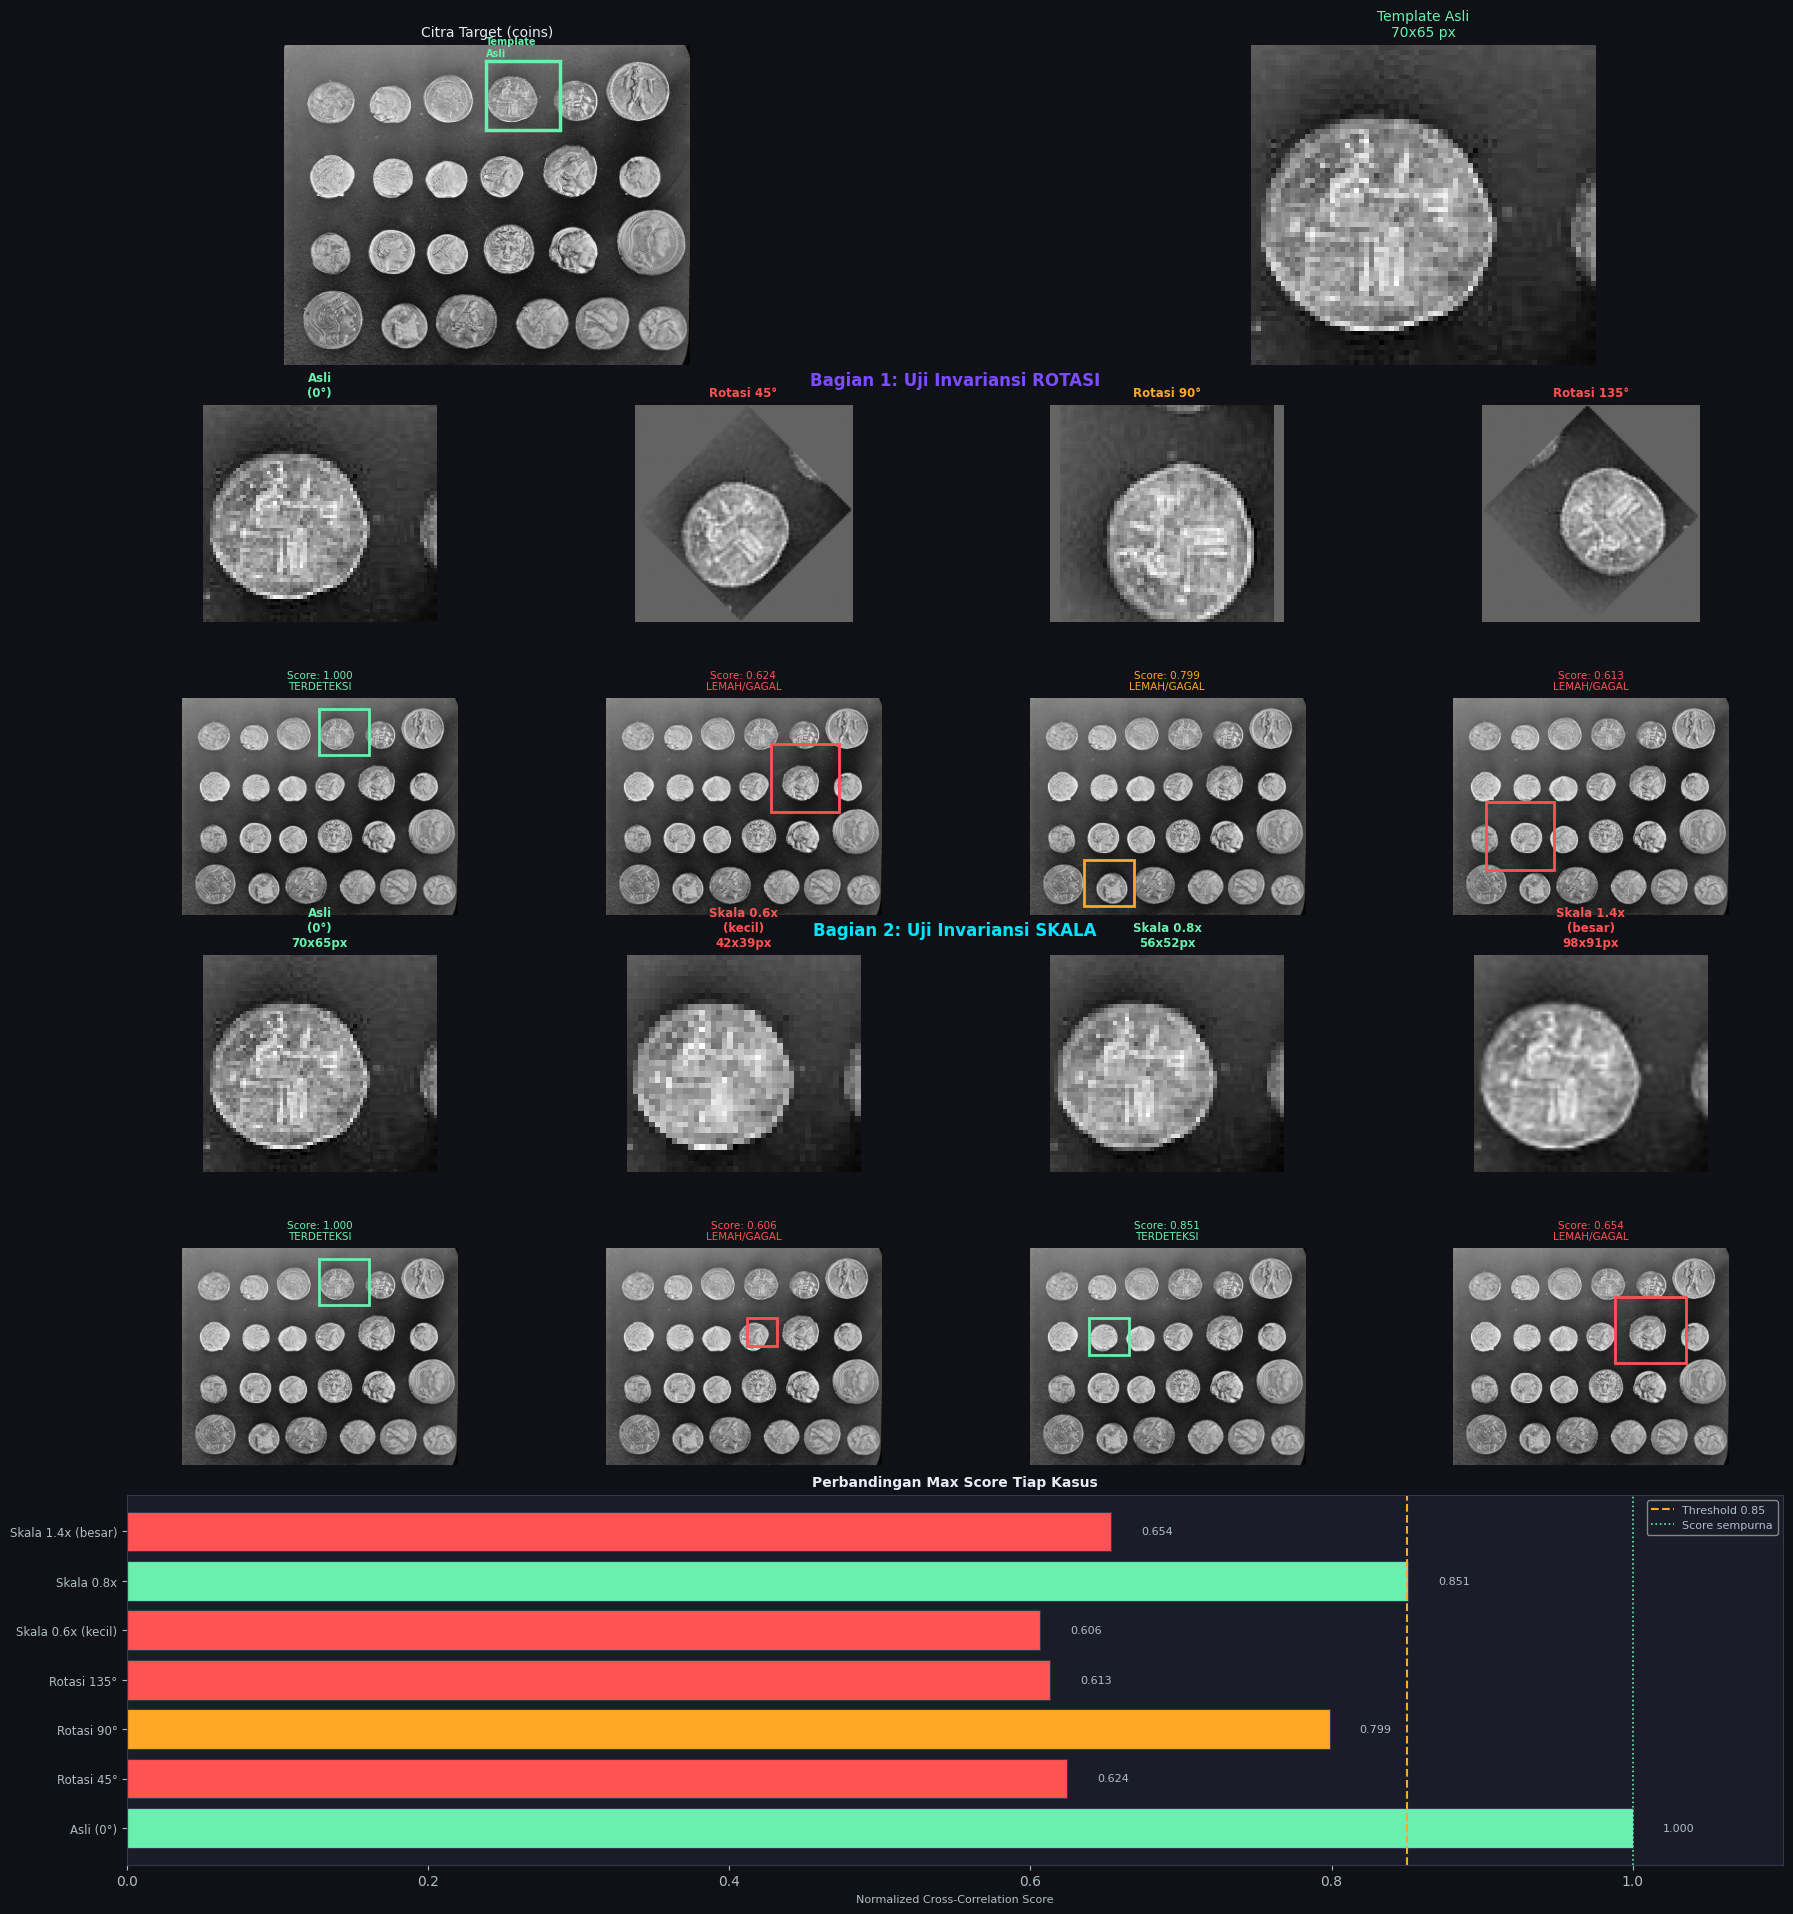

In [14]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from skimage import data, transform
from skimage.feature import match_template
from scipy.ndimage import rotate as ndrotate

# ══════════════════════════════════════════════════════════════
# SETUP DATA
# ══════════════════════════════════════════════════════════════
image    = data.coins()
template = image[15:80, 190:260]   # template asli (koin referensi)

# ── Variasi Rotasi ────────────────────────────────────────────
template_rot45  = ndrotate(template,  45, reshape=True,  cval=int(template.mean()))
template_rot90  = ndrotate(template,  90, reshape=False, cval=int(template.mean()))
template_rot135 = ndrotate(template, 135, reshape=True,  cval=int(template.mean()))

# ── Variasi Skala ─────────────────────────────────────────────
def resize_template(tmpl, scale):
    h, w  = tmpl.shape
    resized = transform.resize(tmpl, (int(h * scale), int(w * scale)),
                               anti_aliasing=True, preserve_range=True)
    return resized.astype(np.uint8)

template_s06 = resize_template(template, 0.6)   # diperkecil 60%
template_s08 = resize_template(template, 0.8)   # diperkecil 80%
template_s14 = resize_template(template, 1.4)   # diperbesar 140%

# ══════════════════════════════════════════════════════════════
# TEMPLATE MATCHING — hitung semua hasil
# ══════════════════════════════════════════════════════════════
def do_match(img, tmpl):
    """Jalankan match_template, kembalikan result map dan koordinat terbaik."""
    result = match_template(img, tmpl)
    ij     = np.unravel_index(np.argmax(result), result.shape)
    y, x   = ij
    h, w   = tmpl.shape
    return result, x, y, h, w

# Semua kasus: (label, template, deskripsi)
cases = [
    ("Asli\n(0°)",         template,      "Referensi"),
    ("Rotasi 45°",         template_rot45,  "Rotasi"),
    ("Rotasi 90°",         template_rot90,  "Rotasi"),
    ("Rotasi 135°",        template_rot135, "Rotasi"),
    ("Skala 0.6x\n(kecil)",template_s06,   "Skala"),
    ("Skala 0.8x",         template_s08,   "Skala"),
    ("Skala 1.4x\n(besar)",template_s14,   "Skala"),
]

results = []
for label, tmpl, kind in cases:
    r, x, y, h, w = do_match(image, tmpl)
    score = r.max()
    results.append((label, tmpl, r, x, y, h, w, score, kind))

# ══════════════════════════════════════════════════════════════
# VISUALISASI
# ══════════════════════════════════════════════════════════════
BG      = '#0F1117'
PANEL   = '#1A1D27'
TITLE_C = '#E8EAF6'
LABEL_C = '#B0BEC5'
GOLD    = '#FFD54F'
GREEN   = '#69F0AE'
RED     = '#FF5252'
ORANGE  = '#FFA726'

fig = plt.figure(figsize=(18, 20), facecolor=BG)

# ── Section (A): Template asli + penjelasan ─────────────────
gs_top = gridspec.GridSpec(1, 2, figure=fig,
                           left=0.04, right=0.96,
                           top=0.945, bottom=0.785,
                           wspace=0.3)

ax_img = fig.add_subplot(gs_top[0])
ax_img.imshow(image, cmap='gray')
ax_img.set_title('Citra Target (coins)', color=TITLE_C, fontsize=10)
ax_img.axis('off')
# tandai area template di citra asli
h0, w0 = template.shape
rect0  = plt.Rectangle((190, 15), w0, h0,
                        edgecolor=GREEN, facecolor='none', linewidth=2.5)
ax_img.add_patch(rect0)
ax_img.text(190, 10, 'Template\nAsli', color=GREEN, fontsize=7, fontweight='bold')

ax_tmpl = fig.add_subplot(gs_top[1])
ax_tmpl.imshow(template, cmap='gray')
ax_tmpl.set_title(f'Template Asli\n{template.shape[1]}x{template.shape[0]} px',
                  color=GREEN, fontsize=10)
ax_tmpl.axis('off')

# ── Section (B): Uji Rotasi ──────────────────────────────────
rot_cases = [c for c in results if c[8] in ("Referensi", "Rotasi")]

fig.text(0.5, 0.775,
         'Bagian 1: Uji Invariansi ROTASI',
         ha='center', fontsize=12, fontweight='bold', color='#7C4DFF')

gs_rot = gridspec.GridSpec(2, len(rot_cases), figure=fig,
                           left=0.04, right=0.96,
                           top=0.765, bottom=0.510,
                           wspace=0.1, hspace=0.35)

for ci, (label, tmpl, r, x, y, h, w, score, kind) in enumerate(rot_cases):
    # baris atas: template
    ax_t = fig.add_subplot(gs_rot[0, ci])
    ax_t.imshow(tmpl, cmap='gray')
    color_lbl = GREEN if score > 0.85 else (ORANGE if score > 0.70 else RED)
    ax_t.set_title(label, color=color_lbl, fontsize=8.5, fontweight='bold')
    ax_t.axis('off')

    # baris bawah: deteksi di image asli
    ax_d = fig.add_subplot(gs_rot[1, ci])
    ax_d.imshow(image, cmap='gray')
    rect = plt.Rectangle((x, y), w, h,
                          edgecolor=color_lbl, facecolor='none', linewidth=2)
    ax_d.add_patch(rect)
    badge = f'Score: {score:.3f}\n{"TERDETEKSI" if score > 0.85 else "LEMAH/GAGAL"}'
    ax_d.set_title(badge, color=color_lbl, fontsize=7.5)
    ax_d.axis('off')

# ── Section (C): Uji Skala ───────────────────────────────────
scale_cases_ref = [c for c in results if c[8] == "Referensi"]
scale_cases     = scale_cases_ref + [c for c in results if c[8] == "Skala"]

fig.text(0.5, 0.500,
         'Bagian 2: Uji Invariansi SKALA',
         ha='center', fontsize=12, fontweight='bold', color='#00E5FF')

gs_scl = gridspec.GridSpec(2, len(scale_cases), figure=fig,
                           left=0.04, right=0.96,
                           top=0.490, bottom=0.235,
                           wspace=0.1, hspace=0.35)

for ci, (label, tmpl, r, x, y, h, w, score, kind) in enumerate(scale_cases):
    ax_t = fig.add_subplot(gs_scl[0, ci])
    ax_t.imshow(tmpl, cmap='gray')
    color_lbl = GREEN if score > 0.85 else (ORANGE if score > 0.70 else RED)
    sh, sw = tmpl.shape
    ax_t.set_title(f'{label}\n{sw}x{sh}px',
                   color=color_lbl, fontsize=8.5, fontweight='bold')
    ax_t.axis('off')

    ax_d = fig.add_subplot(gs_scl[1, ci])
    ax_d.imshow(image, cmap='gray')
    rect = plt.Rectangle((x, y), w, h,
                          edgecolor=color_lbl, facecolor='none', linewidth=2)
    ax_d.add_patch(rect)
    badge = f'Score: {score:.3f}\n{"TERDETEKSI" if score > 0.85 else "LEMAH/GAGAL"}'
    ax_d.set_title(badge, color=color_lbl, fontsize=7.5)
    ax_d.axis('off')

# ── Section (D): Score bar chart + Kesimpulan ───────────────
gs_bot = gridspec.GridSpec(1, 1, figure=fig,
                           left=0.04, right=0.96,
                           top=0.220, bottom=0.035,
                           wspace=0.35)

# Bar chart score
ax_bar = fig.add_subplot(gs_bot[0])
ax_bar.set_facecolor(PANEL)
labels_clean = [c[0].replace('\n', ' ') for c in results]
scores       = [c[7] for c in results]
bar_colors   = [GREEN if s > 0.85 else (ORANGE if s > 0.70 else RED) for s in scores]

bars = ax_bar.barh(range(len(scores)), scores, color=bar_colors,
                   edgecolor='#333654', linewidth=0.8)
ax_bar.set_yticks(range(len(labels_clean)))
ax_bar.set_yticklabels(labels_clean, color=LABEL_C, fontsize=8.5)
ax_bar.set_xlim(0, 1.1)
ax_bar.axvline(x=0.85, color=ORANGE, linestyle='--',
               linewidth=1.5, label='Threshold 0.85')
ax_bar.axvline(x=1.0,  color=GREEN,  linestyle=':',
               linewidth=1.2, label='Score sempurna')
for bar, score in zip(bars, scores):
    ax_bar.text(score + 0.02, bar.get_y() + bar.get_height() / 2,
                f'{score:.3f}', va='center', color=LABEL_C, fontsize=8)
ax_bar.set_title('Perbandingan Max Score Tiap Kasus',
                 color=TITLE_C, fontsize=10, fontweight='bold')
ax_bar.set_xlabel('Normalized Cross-Correlation Score', color=LABEL_C, fontsize=8)
ax_bar.tick_params(colors=LABEL_C)
ax_bar.legend(fontsize=8, facecolor=PANEL, labelcolor=LABEL_C, framealpha=0.6)
for sp in ax_bar.spines.values():
    sp.set_color('#333654')

y_pos = 0.96
for txt, cc, fw, fs in kesimpulan:
    ax_kes.text(0.05, y_pos, txt,
                transform=ax_kes.transAxes,
                color=cc, fontsize=fs, fontweight=fw)
    y_pos -= 0.067

plt.tight_layout()
plt.show()